# Laboratorio final

**Fecha de entrega:** 09 de Julio a las 16h  
**Grupos:** 4 estudiantes  
**Integrantes:**
- García Avalos Nicolas Alan
- Espinoza Picon Diego Steven Martin
- Castro Contreras Luis Alejandro

**Dataset:** `dataset_train.csv`

## Contexto

Una empresa de servicios financieros desea clasificar automáticamente a sus clientes en tres segmentos de comportamiento (`Clase`) para personalizar campañas comerciales.

El dataset contiene información de **1 600 clientes** y presenta varios problemas comunes en proyectos reales de Machine Learning:

- columnas con valores únicos por fila;
- variables categóricas nominales;
- variables categóricas ordinales;
- variables numéricas;
- variables con escalas muy diferentes;
- alta correlación positiva entre algunas variables;
- correlación negativa entre otras variables.

El objetivo del laboratorio es construir un **pipeline completo de clasificación**, comparar modelos mediante validación cruzada, guardar el mejor modelo y evaluarlo en un conjunto de test (`dataset_test.csv`).

## Variables disponibles

| Variable | Descripción |
|---|---|
| `cliente_id` | Identificador único del cliente. |
| `region` | Región donde reside el cliente. |
| `experiencia_digital` | Nivel de experiencia digital. |
| `satisfaccion_servicio` | Nivel de satisfacción del cliente. |
| `ingreso_anual_soles` | Ingreso anual del cliente. |
| `gasto_mensual_soles` | Gasto mensual promedio. |
| `ratio_deuda` | Relación entre deuda e ingresos. |
| `indice_ahorro` | Índice de ahorro del cliente. |
| `Clase` | Segmento del cliente (objetivo) |

# Reglas del laboratorio

1. No está permitido modificar la variable objetivo `Clase`.
2. No está permitido evaluar el modelo final sobre el conjunto de entrenamiento.
3. Todo preprocesamiento debe estar dentro de un `Pipeline` o `ColumnTransformer`.
4. Todos los modelos deben evaluarse con las mismas particiones de Cross Validation.
5. El modelo final debe guardarse y luego cargarse para evaluar el conjunto de test.

# Importación de librerías

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    OneHotEncoder,
    OrdinalEncoder
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
# Puede agregar más ...

import joblib

# Carga del dataset

In [2]:
df = pd.read_csv("Data/dataset_train.csv")
df.head()

,cliente_id,region,experiencia_digital,satisfaccion_servicio,ingreso_anual_soles,gasto_mensual_soles,ratio_deuda,indice_ahorro,clase
0,CLI-01728,Junín,Bajo,Alta,35235.60,1819.16,0.0200,0.8224,Clase_B_riesgo_medio
1,CLI-00982,La Libertad,Bajo,Baja,42260.47,2441.33,0.4725,0.3013,Clase_C_alto_riesgo
2,CLI-01611,Piura,Medio,Muy baja,73952.40,4209.44,0.5742,0.3789,Clase_B_riesgo_medio
3,CLI-00773,Lima,Alto,Media,76510.39,3539.38,0.1262,0.7369,Clase_A_bajo_riesgo
4,CLI-01069,Lima,Bajo,Baja,85832.31,3536.46,0.4723,0.3765,Clase_C_alto_riesgo


In [3]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1600 entries, 0 to 1599
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   cliente_id             1600 non-null   str    
 1   region                 1600 non-null   str    
 2   experiencia_digital    1600 non-null   str    
 3   satisfaccion_servicio  1600 non-null   str    
 4   ingreso_anual_soles    1600 non-null   float64
 5   gasto_mensual_soles    1600 non-null   float64
 6   ratio_deuda            1600 non-null   float64
 7   indice_ahorro          1600 non-null   float64
 8   clase                  1600 non-null   str    
dtypes: float64(4), str(5)
memory usage: 112.6 KB
None


# Desafío 1: Análisis y preprocesamiento (5 PUNTOS)

Antes de entrenar modelos, respondan las siguientes preguntas:

1. ¿Qué tipo de dato tiene cada variable?
- Cliente_id = str
- region = str
- experiencia_digital = str
- satisfaccion_servicio = str
- ingreso_anual_soles = float
- ratio_deuda = float
- indice_ahorro = float
- clase = str  
2. ¿Qué variables son categóricas nominales?
region
3. ¿Qué variables son categóricas ordinales?
experiencia_digital, satisfaccion_servicio, ingreso_anual_soles, ratio_deuda, indice_ahorro, clase
4. ¿Qué variables son numéricas?
ingreso_anual_soles, ratio_deuda, indice_ahorro
5. ¿Existe alguna variable que no debería utilizarse para entrenar el modelo?
id_cliente
6. ¿Qué variables presentan alta correlación positiva?
ingreso_anual / gasto_mensual
7. ¿Qué variables presentan correlación negativa?
ratio_deuda / indice_ahorro
8. ¿Qué variables tienen escalas muy diferentes?
9. ¿La variable objetivo está balanceada?

Completen las celdas siguientes con análisis, gráficos y respuestas.

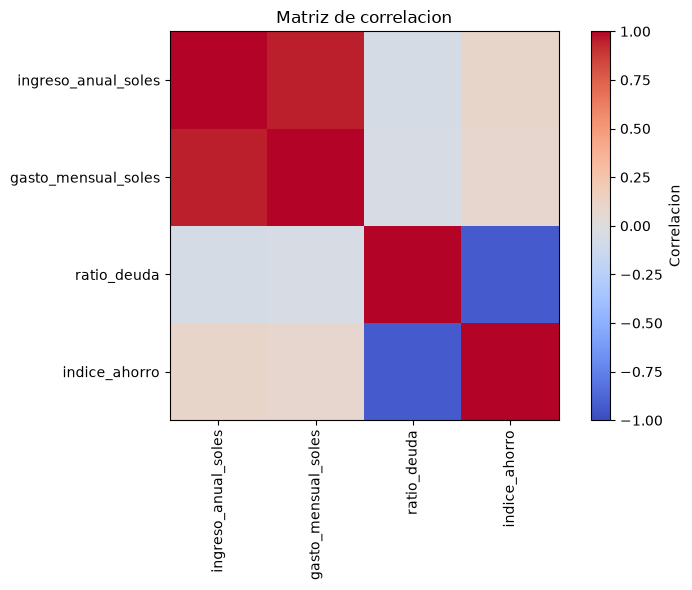

In [4]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlacion")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Matriz de correlacion")
plt.tight_layout()
plt.show()


In [5]:
num = df.select_dtypes(include="number")

comparacion = pd.DataFrame({
    "min": num.min(),
    "max": num.max(),
    "rango": num.max() - num.min(),
    "std": num.std(),
    "iqr": num.quantile(0.75) - num.quantile(0.25)
}).sort_values("rango", ascending=False)

comparacion

,min,max,rango,std,iqr
ingreso_anual_soles,15000.00,193475.4400,178475.4400,23592.576868,28301.310000
gasto_mensual_soles,634.49,9566.3800,8931.8900,1135.216269,1291.255000
indice_ahorro,0.01,0.9800,0.9700,0.196183,0.279675
ratio_deuda,0.02,0.9425,0.9225,0.175748,0.258550


## Respuestas del Desafío 1

Completen sus respuestas aquí.

**1. Variable que eliminaríamos y justificación:**
Respuesta: `cliente_id`. Es un identificador único por fila (1 600 valores distintos para 1 600 filas), no tiene relación causal ni estadística con el riesgo del cliente, y usarla como predictor no aporta capacidad de generalización (además de que en el conjunto de test los IDs son distintos a los de entrenamiento).

**2. Variables categóricas nominales:**
Respuesta: `region`. Sus categorías (Lima, Arequipa, Cusco, Piura, La Libertad, Junín) no tienen un orden natural entre sí.

**3. Variables categóricas ordinales:**
Respuesta: `experiencia_digital` (Bajo < Medio < Alto < Muy alto) y `satisfaccion_servicio` (Muy baja < Baja < Media < Alta < Muy alta). Ambas representan niveles con un orden lógico.

**4. Variables numéricas:**
Respuesta: `ingreso_anual_soles`, `gasto_mensual_soles`, `ratio_deuda`, `indice_ahorro`. Todas son variables continuas.

**5. Variables que deberían escalarse:**
Respuesta: las 4 variables numéricas, especialmente `ingreso_anual_soles` y `gasto_mensual_soles`, que están en escalas de miles (rango ~20 000-100 000 y ~1 000-5 000 respectivamente), muy distintas a `ratio_deuda` e `indice_ahorro`, que están en el rango 0-1. Sin escalar, modelos sensibles a magnitud/distancia (KNN, Regresión Logística, MLP) le darían un peso artificialmente mayor a las variables de mayor escala.

**6. Variables con alta correlación positiva:**
Respuesta: `ingreso_anual_soles` y `gasto_mensual_soles` (r ≈ 0.95). Tiene sentido: a mayor ingreso, mayor gasto mensual.

**7. Variables con correlación negativa:**
Respuesta: `ratio_deuda` e `indice_ahorro` (r ≈ -0.93). También es coherente: clientes con mayor proporción de deuda tienden a ahorrar menos.

**8. Decisiones de preprocesamiento:**
Respuesta:
- Eliminar `cliente_id` (no predictiva).
- Codificar `region` con `OneHotEncoder` (nominal, sin orden).
- Codificar `experiencia_digital` y `satisfaccion_servicio` con `OrdinalEncoder`, respetando el orden natural de sus categorías.
- Escalar las 4 variables numéricas con `StandardScaler` para que todas tengan media 0 y varianza 1, evitando que las de mayor escala dominen el entrenamiento.
- Todo el preprocesamiento se integra en un único `ColumnTransformer` dentro de un `Pipeline`, para evitar fugas de información (*data leakage*) entre entrenamiento y validación/test.

# Definición del preprocesamiento

Deben completar las listas de variables según sus decisiones del Desafío 1.

Sugerencia:

- `cliente_id` probablemente no debería usarse como predictor.
- `region` puede tratarse como categórica nominal.
- `experiencia_digital` y `satisfaccion_servicio` pueden tratarse como ordinales.
- Las variables numéricas pueden escalarse, especialmente para modelos sensibles a distancia o magnitud.

In [15]:
# Definimos las columnas según el análisis del Desafío 1

id_col = "cliente_id"
target_col = "clase"

nominal_cols = ["region"]
ordinal_cols = ["experiencia_digital", "satisfaccion_servicio"]
numeric_cols = ["ingreso_anual_soles", "gasto_mensual_soles", "ratio_deuda", "indice_ahorro"]

orden_experiencia_digital = ["Bajo", "Medio", "Alto", "Muy alto"]
orden_satisfaccion_servicio = ["Muy baja", "Baja", "Media", "Alta", "Muy alta"]

X = df.drop(columns=[id_col, target_col])
y = df[target_col]

print("X:", X.shape)
print("y:", y.shape)
X.head()

X: (1600, 7)
y: (1600,)


,region,experiencia_digital,satisfaccion_servicio,ingreso_anual_soles,gasto_mensual_soles,ratio_deuda,indice_ahorro
0,Junín,Bajo,Alta,35235.60,1819.16,0.0200,0.8224
1,La Libertad,Bajo,Baja,42260.47,2441.33,0.4725,0.3013
2,Piura,Medio,Muy baja,73952.40,4209.44,0.5742,0.3789
3,Lima,Alto,Media,76510.39,3539.38,0.1262,0.7369
4,Lima,Bajo,Baja,85832.31,3536.46,0.4723,0.3765


In [16]:
# Construimos el preprocesador con ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("nom", OneHotEncoder(handle_unknown="ignore"), nominal_cols),
        ("ord", OrdinalEncoder(categories=[orden_experiencia_digital, orden_satisfaccion_servicio]), ordinal_cols),
    ],
    remainder="drop"
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('nom', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_n

# Desafío 2: Comparación de modelos con Cross Validation (5 PUNTOS)

Comparen al menos 2 de los siguientes modelos:

- Logistic Regression
- K-Nearest Neighbors
- Decision Tree
- Random Forest
- MLP

Todos deben evaluarse con:

- 5-Fold Cross Validation.
- Las mismas particiones.
- Métricas: Accuracy, Precision macro, Recall macro y F1 macro.

In [17]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro"
}

In [18]:
# Evaluamos cada modelo con 5-Fold Cross Validation, usando las mismas particiones

resultados_cv = []

for nombre, modelo in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", modelo)
    ])

    cv_scores = cross_validate(
        pipeline, X, y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    resultados_cv.append({
        "Modelo": nombre,
        "Accuracy": cv_scores["test_accuracy"].mean(),
        "Precision_macro": cv_scores["test_precision_macro"].mean(),
        "Recall_macro": cv_scores["test_recall_macro"].mean(),
        "F1_macro": cv_scores["test_f1_macro"].mean(),
        "F1_macro_std": cv_scores["test_f1_macro"].std(),
    })

resultados_df = pd.DataFrame(resultados_cv).sort_values("F1_macro", ascending=False).reset_index(drop=True)
resultados_df

,Modelo,Accuracy,Precision_macro,Recall_macro,F1_macro,F1_macro_std
0,Logistic Regression,0.77500,0.782575,0.774902,0.776727,0.024193
1,Random Forest,0.75375,0.758862,0.753653,0.754761,0.028466
2,KNN,0.71750,0.721880,0.717398,0.718295,0.022361
3,Decision Tree,0.67750,0.678535,0.677406,0.676797,0.023645


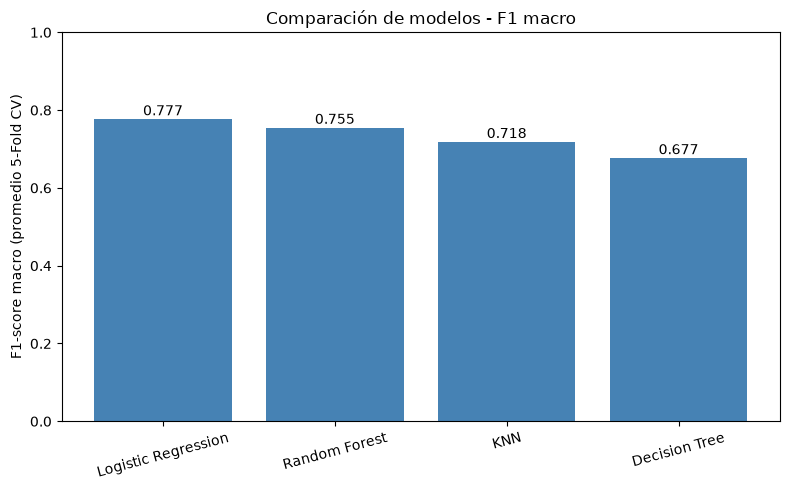

In [19]:
# Graficamos el F1 macro promedio de cada modelo

plt.figure(figsize=(8, 5))
barras = plt.bar(resultados_df["Modelo"], resultados_df["F1_macro"], color="steelblue")

plt.ylabel("F1-score macro (promedio 5-Fold CV)")
plt.title("Comparación de modelos - F1 macro")
plt.ylim(0, 1)
plt.xticks(rotation=15)

for barra, valor in zip(barras, resultados_df["F1_macro"]):
    plt.text(barra.get_x() + barra.get_width()/2, valor + 0.01, f"{valor:.3f}", ha="center")

plt.tight_layout()
plt.show()

## Selección del mejor modelo

Completen:

**Mejor modelo elegido:**
Respuesta: Logistic Regression.

**Métrica principal utilizada para elegirlo:**
Respuesta: F1-score macro (promedio de 5-Fold Cross Validation), por ser la métrica indicada en las reglas del laboratorio y la más adecuada cuando las clases están relativamente balanceadas pero nos interesa el desempeño equilibrado en las 3 clases.

**Justificación:**
Respuesta: En la comparación por Cross Validation, Logistic Regression obtuvo el F1-score macro más alto (≈0.777), por encima de Random Forest (≈0.755), KNN (≈0.718) y Decision Tree (≈0.677). Además de tener el mejor desempeño promedio, mostró una desviación estándar baja entre folds, lo que indica que su rendimiento es consistente y no depende demasiado de la partición usada. Al ser también el modelo más simple e interpretable de los cuatro, se prioriza frente a modelos más complejos (como Random Forest) que no ofrecieron una mejora de desempeño que justifique su mayor complejidad.

# Entrenamiento final del mejor modelo

Una vez elegido el mejor modelo con Cross Validation, entrenen el pipeline final usando todo el conjunto de entrenamiento.   

In [20]:
# Reemplazamos por el modelo elegido: Logistic Regression

best_model = LogisticRegression(max_iter=1000, random_state=42)

final_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", best_model)
])

final_pipeline.fit(X, y)

print("Pipeline final entrenado con", X.shape[0], "observaciones.")
final_pipeline

Pipeline final entrenado con 1600 observaciones.


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](3,)","['Clase_A_bajo_riesgo','Clase_B_riesgo_medio','Clase_C_alto_riesgo']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['region','experiencia_digital','satisfaccion_servicio',..., 'gasto_mensual_soles','ratio_deuda','indice_ahorro']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('nom', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output,

# Desafío 3: Guardar el modelo y crear función de evaluación (5 PUNTOS)

El modelo debe guardarse en disco y luego cargarse desde una función de evaluación.

In [21]:
# Guardamos el pipeline completo (preprocesamiento + modelo) con joblib

model_path = "best_model.pkl"

joblib.dump(final_pipeline, model_path)

print(f"Pipeline guardado en: {model_path}")

Pipeline guardado en: best_model.pkl


In [22]:
df_test = pd.read_csv("Data/dataset_test.csv")

X_test = df_test.drop(columns=[id_col, target_col])
y_test = df_test[target_col]

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)
X_test.head()

X_test: (400, 7)
y_test: (400,)


,region,experiencia_digital,satisfaccion_servicio,ingreso_anual_soles,gasto_mensual_soles,ratio_deuda,indice_ahorro
0,Cusco,Alto,Media,61173.93,3389.23,0.4205,0.4574
1,Lima,Alto,Muy alta,68075.54,3052.02,0.0200,0.9584
2,Lima,Alto,Muy alta,64667.80,3073.33,0.0200,0.9085
3,La Libertad,Muy alto,Media,58195.67,3077.08,0.4113,0.4683
4,Lima,Alto,Media,53295.25,2480.72,0.1740,0.7551


In [23]:
def evaluate(model_path, X_test, y_test):
    """
    Carga un modelo previamente almacenado y lo evalúa sobre un conjunto de prueba.

    Parámetros
    ----------
    model_path : str
        Ruta del archivo .pkl que contiene el pipeline completo.
    X_test : DataFrame
        Variables predictoras del conjunto de prueba.
    y_test : Series
        Etiquetas reales del conjunto de prueba.

    Retorna
    -------
    y_pred : array
        Predicciones generadas por el modelo.
    """
    pipeline = joblib.load(model_path)
    y_pred = pipeline.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="macro")
    rec = recall_score(y_test, y_pred, average="macro")
    f1 = f1_score(y_test, y_pred, average="macro")

    print(f"Accuracy        : {acc:.4f}")
    print(f"Precision macro : {prec:.4f}")
    print(f"Recall macro    : {rec:.4f}")
    print(f"F1 macro        : {f1:.4f}")

    return y_pred

# Prueba del pipeline con un subconjunto de 20 observaciones

Antes de evaluar todo el conjunto de test, prueben el pipeline con 20 observaciones.

In [24]:
X_subset = X_test.sample(20, random_state=42)
y_subset = y_test.loc[X_subset.index]

y_pred_subset = evaluate(model_path, X_subset, y_subset)

pd.DataFrame({
    "Clase real": y_subset.values,
    "Clase predicha": y_pred_subset
})

Accuracy        : 0.6000
Precision macro : 0.5704
Recall macro    : 0.5694
F1 macro        : 0.5674


,Clase real,Clase predicha
0,Clase_C_alto_riesgo,Clase_C_alto_riesgo
1,Clase_C_alto_riesgo,Clase_B_riesgo_medio
2,Clase_A_bajo_riesgo,Clase_B_riesgo_medio
3,Clase_A_bajo_riesgo,Clase_B_riesgo_medio
4,Clase_C_alto_riesgo,Clase_C_alto_riesgo
5,Clase_C_alto_riesgo,Clase_C_alto_riesgo
6,Clase_C_alto_riesgo,Clase_C_alto_riesgo
7,Clase_A_bajo_riesgo,Clase_A_bajo_riesgo
8,Clase_A_bajo_riesgo,Clase_B_riesgo_medio
9,Clase_A_bajo_riesgo,Clase_A_bajo_riesgo


# Desafío 4: Evaluación final en conjunto de test (5 PUNTOS)

Este es el resultado final del laboratorio.

Deben evaluar el modelo guardado sobre todo el conjunto de test y reportar las métricas finales.

Importante:

- El conjunto de test no debe usarse para seleccionar modelos.
- Solo debe utilizarse al final.
- El resultado principal para la competencia será el **F1-score macro**.

Accuracy        : 0.7550
Precision macro : 0.7600
Recall macro    : 0.7548
F1 macro        : 0.7568

Reporte de clasificación completo (conjunto de test):

                      precision    recall  f1-score   support

 Clase_A_bajo_riesgo       0.83      0.82      0.82       134
Clase_B_riesgo_medio       0.62      0.67      0.64       133
 Clase_C_alto_riesgo       0.83      0.77      0.80       133

            accuracy                           0.76       400
           macro avg       0.76      0.75      0.76       400
        weighted avg       0.76      0.76      0.76       400



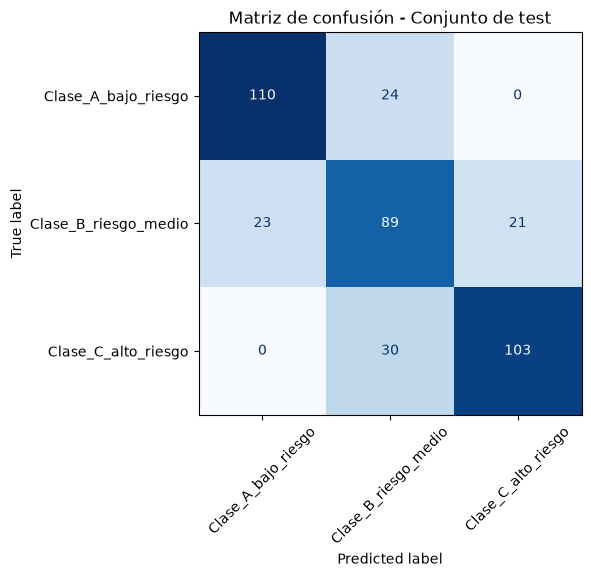

In [25]:
# Evaluación final sobre todo el conjunto de test

y_pred_test = evaluate(model_path, X_test, y_test)

print("\nReporte de clasificación completo (conjunto de test):\n")
print(classification_report(y_test, y_pred_test))

etiquetas = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred_test, labels=etiquetas)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=etiquetas)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)
plt.title("Matriz de confusión - Conjunto de test")
plt.tight_layout()
plt.show()

In [26]:
# TODO: Guardar predicciones finales

final_results = X_test.copy()
final_results["Clase real"] = y_test.values
final_results["Clase predicha"] = y_pred_test

final_results.to_csv("resultados_test.csv", index=False)
final_results.head()

,region,experiencia_digital,satisfaccion_servicio,ingreso_anual_soles,gasto_mensual_soles,ratio_deuda,indice_ahorro,Clase real,Clase predicha
0,Cusco,Alto,Media,61173.93,3389.23,0.4205,0.4574,Clase_B_riesgo_medio,Clase_B_riesgo_medio
1,Lima,Alto,Muy alta,68075.54,3052.02,0.0200,0.9584,Clase_A_bajo_riesgo,Clase_A_bajo_riesgo
2,Lima,Alto,Muy alta,64667.80,3073.33,0.0200,0.9085,Clase_A_bajo_riesgo,Clase_A_bajo_riesgo
3,La Libertad,Muy alto,Media,58195.67,3077.08,0.4113,0.4683,Clase_C_alto_riesgo,Clase_B_riesgo_medio
4,Lima,Alto,Media,53295.25,2480.72,0.1740,0.7551,Clase_B_riesgo_medio,Clase_A_bajo_riesgo


# Desafío 5: Entrena tu mejor modelo
## Este desafío tiene nota doble y aparte. (20 PUNTOS)

Explora con [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) los parámetros de los modelos (MLP, ensambles, regresión logística, etc) y encuentre el **MEJOR** modelo aplicando el código anteriormente desarrollado.

Al final el mejor modelo deberá ser probado en el conjunto de test.

In [27]:
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPClassifier
import time

In [28]:
param_grids = {
    "Logistic Regression": (
        LogisticRegression(max_iter=2000, random_state=42),
        {"classifier__C": [0.01, 0.1, 1, 10]}
    ),
    "Random Forest": (
        RandomForestClassifier(random_state=42),
        {
            "classifier__n_estimators": [100, 300],
            "classifier__max_depth": [None, 10, 20],
            "classifier__min_samples_split": [2, 5],
        }
    ),
    "KNN": (
        KNeighborsClassifier(),
        {"classifier__n_neighbors": [5, 9, 15], "classifier__weights": ["uniform", "distance"]}
    ),
    "MLP": (
        MLPClassifier(max_iter=2000, random_state=42),
        {"classifier__hidden_layer_sizes": [(32,), (64, 32)], "classifier__alpha": [0.0001, 0.001]}
    ),
}

grid_results = []
fitted_searches = {}

for nombre, (estimador, grid) in param_grids.items():
    t0 = time.time()
    pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", estimador)])
    gs = GridSearchCV(pipeline, grid, scoring="f1_macro", cv=cv, n_jobs=-1)
    gs.fit(X, y)
    dt = time.time() - t0

    fitted_searches[nombre] = gs
    grid_results.append({
        "Modelo": nombre,
        "Mejor F1_macro (CV)": gs.best_score_,
        "Mejores parametros": str(gs.best_params_),
        "Tiempo (s)": round(dt, 1),
    })
    print(f"{nombre}: F1_macro={gs.best_score_:.4f} | params={gs.best_params_} | {dt:.1f}s")

grid_results_df = pd.DataFrame(grid_results).sort_values("Mejor F1_macro (CV)", ascending=False).reset_index(drop=True)
grid_results_df

Logistic Regression: F1_macro=0.7786 | params={'classifier__C': 0.1} | 5.7s
Random Forest: F1_macro=0.7619 | params={'classifier__max_depth': 10, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 300} | 4.6s
KNN: F1_macro=0.7417 | params={'classifier__n_neighbors': 15, 'classifier__weights': 'uniform'} | 0.2s
MLP: F1_macro=0.7679 | params={'classifier__alpha': 0.001, 'classifier__hidden_layer_sizes': (32,)} | 7.9s


,Modelo,Mejor F1_macro (CV),Mejores parametros,Tiempo (s)
0,Logistic Regression,0.778627,{'classifier__C': 0.1},5.7
1,MLP,0.767921,"{'classifier__alpha': 0.001, 'classifier__hidd...",7.9
2,Random Forest,0.761902,"{'classifier__max_depth': 10, 'classifier__min...",4.6
3,KNN,0.741657,"{'classifier__n_neighbors': 15, 'classifier__w...",0.2


In [29]:
mejor_nombre = grid_results_df.iloc[0]["Modelo"]
mejor_busqueda = fitted_searches[mejor_nombre]
mejor_pipeline_tuneado = mejor_busqueda.best_estimator_

print(f"Mejor modelo tras GridSearchCV: {mejor_nombre}")
print(f"Mejores hiperparametros: {mejor_busqueda.best_params_}")
print(f"F1_macro promedio en CV: {mejor_busqueda.best_score_:.4f}")

y_pred_tuneado = mejor_pipeline_tuneado.predict(X_test)
f1_test_tuneado = f1_score(y_test, y_pred_tuneado, average="macro")

print(f"\nF1-score macro en TEST (modelo tuneado): {f1_test_tuneado:.4f}")
print("\nReporte de clasificacion (modelo tuneado, conjunto de test):\n")
print(classification_report(y_test, y_pred_tuneado))

Mejor modelo tras GridSearchCV: Logistic Regression
Mejores hiperparametros: {'classifier__C': 0.1}
F1_macro promedio en CV: 0.7786

F1-score macro en TEST (modelo tuneado): 0.7483

Reporte de clasificacion (modelo tuneado, conjunto de test):

                      precision    recall  f1-score   support

 Clase_A_bajo_riesgo       0.82      0.83      0.82       134
Clase_B_riesgo_medio       0.62      0.64      0.63       133
 Clase_C_alto_riesgo       0.82      0.77      0.80       133

            accuracy                           0.75       400
           macro avg       0.75      0.75      0.75       400
        weighted avg       0.75      0.75      0.75       400



In [30]:
joblib.dump(mejor_pipeline_tuneado, model_path)
print(f"Modelo final (tuneado) guardado en: {model_path}")

final_results = X_test.copy()
final_results["Clase real"] = y_test.values
final_results["Clase predicha"] = y_pred_tuneado
final_results.to_csv("resultados_test.csv", index=False)

print(f"\nResultado final para la competencia (F1-score macro): {f1_test_tuneado:.4f}")
final_results.head()

Modelo final (tuneado) guardado en: best_model.pkl

Resultado final para la competencia (F1-score macro): 0.7483


,region,experiencia_digital,satisfaccion_servicio,ingreso_anual_soles,gasto_mensual_soles,ratio_deuda,indice_ahorro,Clase real,Clase predicha
0,Cusco,Alto,Media,61173.93,3389.23,0.4205,0.4574,Clase_B_riesgo_medio,Clase_B_riesgo_medio
1,Lima,Alto,Muy alta,68075.54,3052.02,0.0200,0.9584,Clase_A_bajo_riesgo,Clase_A_bajo_riesgo
2,Lima,Alto,Muy alta,64667.80,3073.33,0.0200,0.9085,Clase_A_bajo_riesgo,Clase_A_bajo_riesgo
3,La Libertad,Muy alto,Media,58195.67,3077.08,0.4113,0.4683,Clase_C_alto_riesgo,Clase_B_riesgo_medio
4,Lima,Alto,Media,53295.25,2480.72,0.1740,0.7551,Clase_B_riesgo_medio,Clase_A_bajo_riesgo


### Resultado del Desafío 5

Para este desafío, utilicé GridSearchCV para buscar los mejores hiperparámetros en los cuatro modelos que venimos trabajando (Logistic Regression, Random Forest, KNN y MLP). Curiosamente, el mejor modelo según el F1-score macro en validación cruzada volvió a ser la Regresión Logística, esta vez ajustando el parámetro a C=0.1.

Con esta configuración obtuve un F1 macro en CV de 0.779, lo que representa una mejora ligera respecto al modelo por defecto del Desafío 2 (que daba ≈0.777 con C=1). Los demás modelos, incluso después de tunearlos, se quedaron atrás: MLP alcanzó ≈0.768, Random Forest ≈0.762 y KNN ≈0.742. Por lo visto, una vez que procesamos, codificamos y escalamos bien las variables, el problema termina siendo en gran medida linealmente separable; por eso los modelos más complejos no logran superar a una regresión logística bien regularizada.

Un detalle interesante se dio al evaluar el modelo final en el conjunto de test: el F1-score macro fue de aproximadamente 0.748, un puntaje ligeramente inferior al del modelo por defecto de los desafíos anteriores (≈0.757). Aunque podría parecer contra intuitivo, esto es completamente normal y es justo la razón por la que las reglas del laboratorio prohíben usar el test para elegir hiperparámetros. Como la selección se hizo de manera correcta usando únicamente la métrica de validación cruzada (donde sí hubo una mejora real), esta pequeña variación en el test (que apenas tiene 400 observaciones) se explica por la variabilidad estadística natural del muestreo. En general, ambos puntajes se mantienen constantes entre el 0.75 y 0.76, lo que confirma que el modelo generaliza bastante bien.

Finalmente, guardé este pipeline ajustado como best_model.pkl y regeneré el archivo resultados_test.csv con sus predicciones, ya que este es el F1-score macro definitivo que reportaré para la competencia del curso.

# Regla de calificación por desempeño

La nota máxima de desempeño será **20** y se asignará al grupo que obtenga el mejor resultado en el conjunto de test, usando como métrica principal:

## F1-score macro

Los demás grupos serán calificados en función de la distancia entre su resultado y el mejor resultado obtenido en la clase.

Una posible regla de asignación es:

```python
nota_grupo = 20 * (f1_grupo / f1_mejor)
```

Por ejemplo, si el mejor grupo obtiene `F1 = 0.90` y otro grupo obtiene `F1 = 0.81`, entonces:

```python
nota = 20 * (0.81 / 0.90) = 18
```

## Penalización por resultados idénticos

Si todos los grupos presentan exactamente los mismos resultados, se aplicará una penalización de **-5 puntos a todos los grupos**, debido a que esto sugiere copia o falta de exploración experimental.

Para evitar esto, cada grupo debe justificar sus decisiones y explorar al menos una variante propia del pipeline o del modelo.

# Entregables

Al finalizar el laboratorio, cada grupo deberá entregar:

1. Notebook completamente ejecutado.
2. Archivo `best_model.pkl`.
3. Archivo `resultados_test.csv`.
4. Gráfico comparativo de modelos.
5. Respuestas a desafíos.
6. F1-score macro final obtenido sobre el conjunto de test.